In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
import alphacnn

# Define BC field

In [4]:
# Define number of synapses per dendrite length
synapses_per_um_dendrite = 0.39

In [5]:
pixelsize = 10
field_xlim = (-300, 300)
field_ylim = (-300, 300)
bc_area = 227.

In [6]:
from alphacnn.geometry import field
from alphacnn.geometry import grid

field = field.Field(pixelsize=pixelsize, field_xlim=field_xlim, field_ylim=field_ylim)
bc_cxys, bc_hxys, _, _ = grid.get_hex_grid(xlim=field.field_xlim, ylim=field.field_ylim, area=bc_area, verbose=1)

cdist=16, area=2.3e+02, ri=8.1, ru=9.3
x in -2.8e+02 to 2.8e+02
y in -2.8e+02 to 2.8e+02


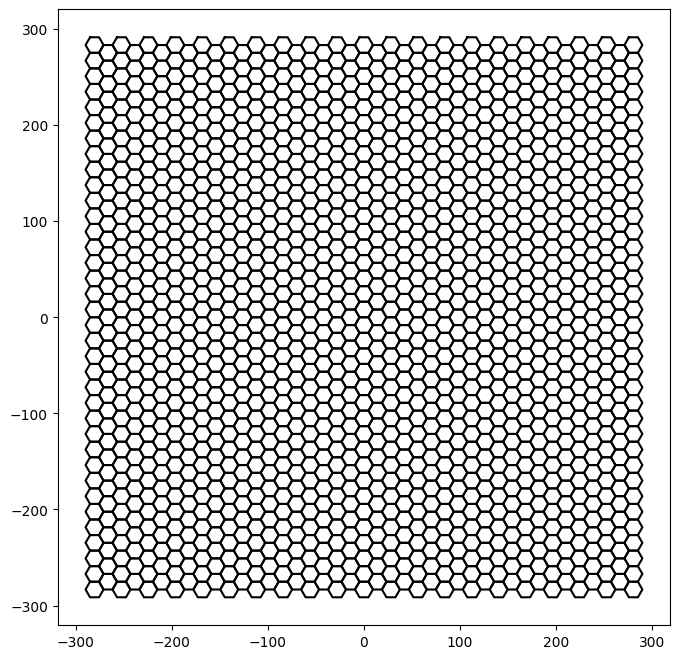

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
grid.plot_grid(bc_cxys, bc_hxys, ax=ax, hex_kws=dict(c='k'), scatter_kws=dict(c='r', s=6));

# Load data

In [8]:
from alphacnn.paths import PROJECT_ROOT

folder_figures = "./figures"
folder_data = os.path.join(PROJECT_ROOT, "../../data/Model/dendrite_densities")

assert os.path.isdir(folder_figures), f"Create folder: {folder_figures}"
assert os.path.isdir(folder_data), f"Create folder: {folder_data}"

In [9]:
from alphacnn.utils import data_utils
from alphacnn import geometry

In [10]:
load_data = True

if load_data:
    df_cells = data_utils.load_var(f'{folder_data}/df_dendrite_densities.pkl')
else:
    assert os.system(f'python3 load_data.py calcium {folder_data}') == 0
    assert os.system(f'python3 load_data.py glutamate {folder_data}') == 0

In [11]:
if not load_data:
    df_cells = pd.concat(
        [data_utils.load_var(f'{folder_data}/df_calcium.pkl'), data_utils.load_var(f'{folder_data}/df_glutamate.pkl')],
        ignore_index=True)

    df_cells['morph'] = None
    
    for experiment, row in df_cells.iterrows():
        morph = geometry.morphology.Morphology(df_paths=row.df_paths, soma_xyz=row.soma_xyz, cxys=bc_cxys, hxys=bc_hxys)
        morph.compute_length_per_area()
        df_cells.at[row.name, 'morph'] = morph
        
for col in ['linestack', 'density_map', 'line_stratification_yz', 'density_map_extent']:
    if col in df_cells.columns:
        df_cells.drop(col, axis=1)

if not load_data:
    data_utils.save_var(df_cells, f'{folder_data}/df_dendrite_densities.pkl')

In [12]:
assert "morph" in df_cells.columns, df_cells.columns
from IPython.display import clear_output

plot_data = False

if plot_data:
    for experiment, row in df_cells.iterrows():
        clear_output(wait=True)
        ax = row.morph.plot()
        sns.despine()
        plt.savefig(f'{folder_figures}/{row.indicator}_{experiment}.pdf')
        plt.show()

# Fit 1d fun

In [13]:
for experiment, row in df_cells.iterrows():
    row.morph.fit_truncated_normal()

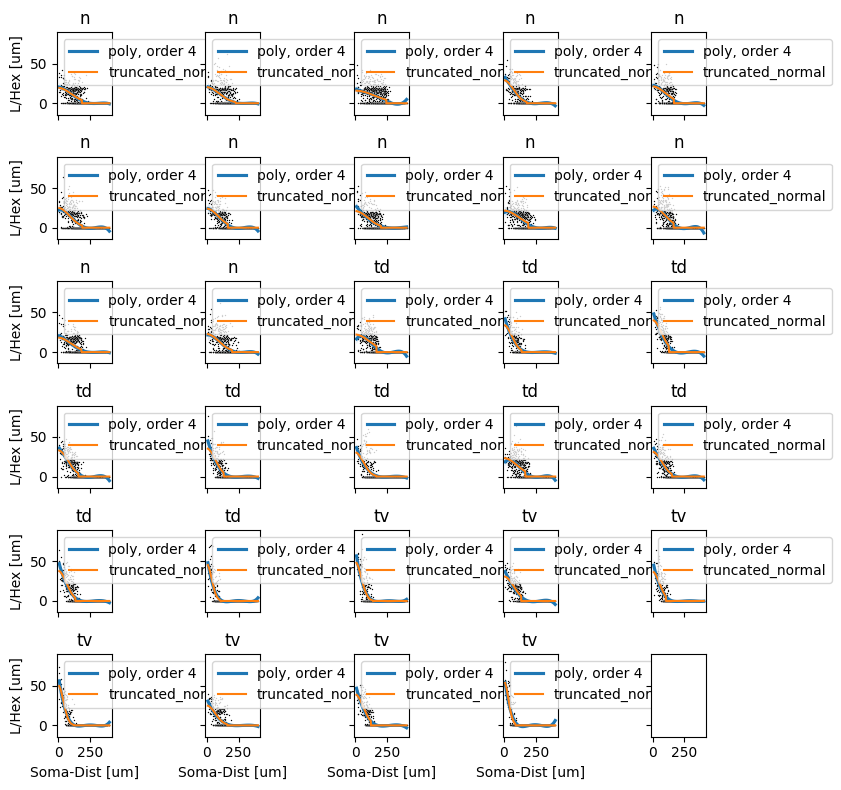

In [14]:
fig, axs = plt.subplots(6, 5, figsize=(8, 8), sharex='all', sharey='all')

for ax, (experiment, row) in zip(axs.flat, df_cells.sort_values('n_tvd_side').iterrows()):
    ax.set_title(row.n_tvd_side)
    row.morph.plot_fit(ax=ax)

plt.tight_layout()

In [15]:
df_cells['dend_length_tot'] = df_cells.morph.apply(lambda x: x.line_lengths.sum())

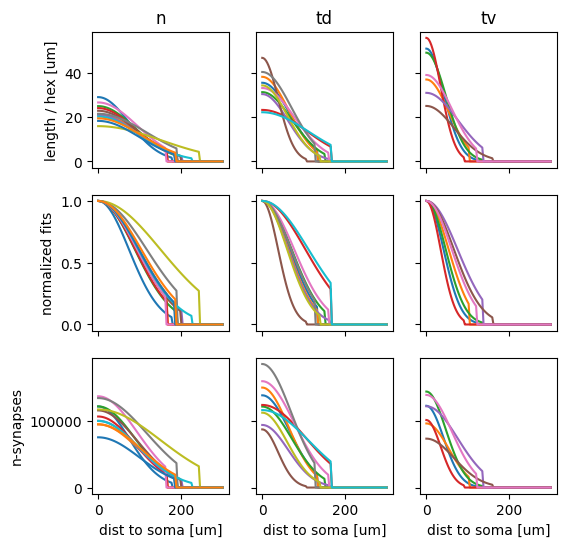

In [16]:
x = np.linspace(0, 300, 101)

groups = df_cells.groupby('n_tvd_side')

fig, axs = plt.subplots(3, len(groups), figsize=(len(groups) * 2, 3 * 2), sharex='all', sharey='row')

for ax_col, (side, group) in zip(axs.T, groups):

    ax_col[0].set_title(side)
    for experiment, row in group.iterrows():
        y = row.morph.get_yfit(x)

        ax_col[0].plot(x, y)
        ax_col[1].plot(x, y / y.max())
        ax_col[2].plot(x, y * row.dend_length_tot)

axs[0, 0].set(ylabel='length / hex [um]')
axs[1, 0].set(ylabel='normalized fits')
axs[2, 0].set(ylabel='n-synapses')

for ax in axs[-1, :]:
    ax.set(xlabel='dist to soma [um]')

In [17]:
df_cells['opt_fit_scale'] = df_cells.morph.apply(lambda r: r.opt_fit.x[0])
df_cells['opt_fit_std'] = df_cells.morph.apply(lambda r: r.opt_fit.x[1])
df_cells['opt_fit_xcut'] = df_cells.morph.apply(lambda r: r.opt_fit.x[2])
df_cells['nsynapses'] = df_cells.dend_length_tot.apply(lambda x: x * synapses_per_um_dendrite)

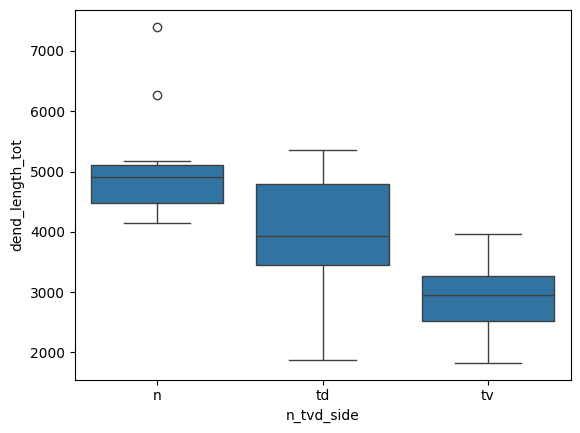

In [18]:
import seaborn as sns

sns.boxplot(data=df_cells.sort_values('n_tvd_side'), x='n_tvd_side', y='dend_length_tot');

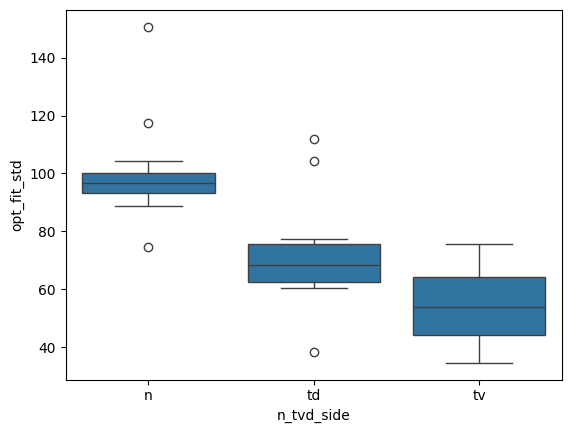

In [19]:
sns.boxplot(data=df_cells.sort_values('n_tvd_side'), x='n_tvd_side', y='opt_fit_std');

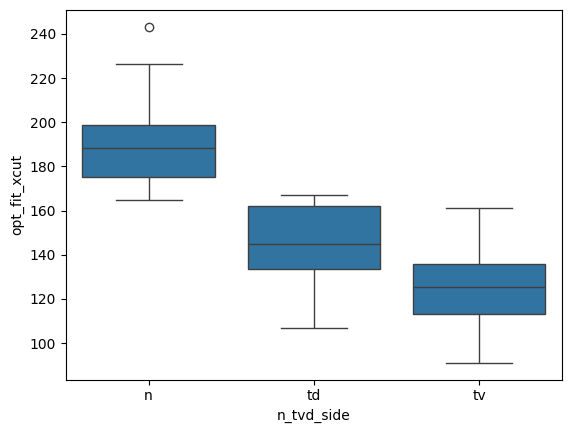

In [20]:
sns.boxplot(data=df_cells.sort_values('n_tvd_side'), x='n_tvd_side', y='opt_fit_xcut');

# Define functions for model

In [21]:
# Standard deviation
df_cells.groupby('n_tvd_side').opt_fit_std.mean()

n_tvd_side
n     100.450442
td     72.622596
tv     54.369099
Name: opt_fit_std, dtype: float64

In [22]:
# Cut off distance
df_cells.groupby('n_tvd_side').opt_fit_xcut.mean()

n_tvd_side
n     191.248517
td    144.707017
tv    125.071735
Name: opt_fit_xcut, dtype: float64

In [23]:
# Total number of synapses
df_cells.groupby('n_tvd_side').nsynapses.mean()

n_tvd_side
n     1975.699575
td    1565.147200
tv    1131.138457
Name: nsynapses, dtype: float64

# Save

In [24]:
data_utils.save_var(df_cells, f'{folder_data}/df_dendrite_densities.pkl')